In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    LSTM, InputLayer, Input, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping


In [5]:
# ============================================================
# 0. Seed
# ============================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
# ============================================================
# 1. Load data
# ============================================================
file_path = r"D:\dataset\2017.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

print("원본 shape:", df.shape)
print("\n원본 라벨 분포:")
print(df["Label"].value_counts())

원본 shape: (543734, 79)

원본 라벨 분포:
Label
BENIGN                        201666
PortScan                      100833
DoS Hulk                      100833
DDoS                          100833
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64


In [11]:
# ============================================================
# 2. Label cleanup
# ============================================================
def clean_label(x):
    x = str(x).strip()
    x = x.replace("�", "-").replace("–", "-")
    x = x.replace("Web Attack � Brute Force", "Web Attack - Brute Force")
    x = x.replace("Web Attack � XSS", "Web Attack - XSS")
    x = x.replace("Web Attack � Sql Injection", "Web Attack - Sql Injection")
    return x

df["Label"] = df["Label"].apply(clean_label)

In [13]:
# ============================================================
# 3. Label regrouping
#    Web만 통합, 나머지는 유지
# ============================================================
def map_attack_family(label):
    label = str(label).strip()

    if label == "BENIGN":
        return "BENIGN"
    elif label == "Bot":
        return "Bot"
    elif label == "DDoS":
        return "DDoS"
    elif label == "DoS GoldenEye":
        return "DoS GoldenEye"
    elif label == "DoS Hulk":
        return "DoS Hulk"
    elif label == "DoS Slowhttptest":
        return "DoS Slowhttptest"
    elif label == "DoS slowloris":
        return "DoS slowloris"
    elif label == "FTP-Patator":
        return "FTP-Patator"
    elif label == "SSH-Patator":
        return "SSH-Patator"
    elif label == "PortScan":
        return "PortScan"
    elif label in [
        "Web Attack - Brute Force",
        "Web Attack - XSS",
        "Web Attack - Sql Injection"
    ]:
        return "Web Attack"
    else:
        return "Other"

df["AttackFamily"] = df["Label"].apply(map_attack_family)
df = df[df["AttackFamily"] != "Other"].copy()

print("\n재구성 후 라벨 분포:")
print(df["AttackFamily"].value_counts())


재구성 후 라벨 분포:
AttackFamily
BENIGN              201666
PortScan            100833
DoS Hulk            100833
DDoS                100833
DoS GoldenEye        10293
FTP-Patator           7938
SSH-Patator           5897
DoS slowloris         5796
DoS Slowhttptest      5499
Web Attack            2180
Bot                   1966
Name: count, dtype: int64


In [15]:
# ============================================================
# 4. Shortcut-learning risk feature drop
# ============================================================
drop_cols = []

for col in df.columns:
    col_lower = col.lower()
    if "destination port" in col_lower:
        drop_cols.append(col)

id_keywords = ["flow id", "src ip", "dst ip", "timestamp", "source ip", "destination ip", "src port"]
for col in df.columns:
    col_lower = col.lower()
    for kw in id_keywords:
        if kw in col_lower:
            drop_cols.append(col)

drop_cols = list(set(drop_cols))
print("\n실제로 drop되는 컬럼:", drop_cols)

df = df.drop(columns=drop_cols, errors="ignore")


실제로 drop되는 컬럼: ['Destination Port']


In [17]:
# ============================================================
# 5. Numeric cleanup
# ============================================================
# Label, AttackFamily 제외 나머지 숫자 변환
for c in df.columns:
    if c not in ["Label", "AttackFamily"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df.replace([np.inf, -np.inf], np.nan, inplace=True)

before = len(df)
df = df.dropna().copy()
print(f"\n결측 제거: {before} -> {len(df)}")

if "Flow Duration" in df.columns:
    before = len(df)
    df = df[df["Flow Duration"] >= 0].copy()
    print(f"음수 Flow Duration 제거: {before} -> {len(df)}")

# 상수 컬럼 제거
nunique = df.nunique()
constant_cols = [c for c in nunique[nunique <= 1].index if c not in ["Label", "AttackFamily"]]
print("\n상수 컬럼:", constant_cols)
df = df.drop(columns=constant_cols, errors="ignore")

print("\n정리 후 shape:", df.shape)



결측 제거: 543734 -> 543067
음수 Flow Duration 제거: 543067 -> 543058

상수 컬럼: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

정리 후 shape: (543058, 69)


In [19]:
# ============================================================
# 6. Feature / target split
# ============================================================
X = df.drop(columns=["Label", "AttackFamily"])
y = df["AttackFamily"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

class_names = list(le.classes_)
num_classes = len(class_names)
num_features = X.shape[1]

print("\n클래스 목록:", class_names)
print("클래스 수:", num_classes)
print("특성 수:", num_features)



클래스 목록: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']
클래스 수: 11
특성 수: 67


In [21]:
# ============================================================
# 7. Train / Test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)


In [23]:
# ============================================================
# 8. Scaling
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# CNN/LSTM 계열용 reshape
X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_seq = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)


In [25]:
# ============================================================
# 9. Model builders
# ============================================================
def build_mlp(input_dim, n_classes):
    model = Sequential([
        InputLayer(input_shape=(input_dim,)),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [27]:
def build_dnn(input_dim, n_classes):
    model = Sequential([
        InputLayer(input_shape=(input_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [29]:
def build_cnn(input_dim, n_classes):
    model = Sequential([
        InputLayer(input_shape=(input_dim, 1)),
        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [31]:
def build_lstm(input_dim, n_classes):
    model = Sequential([
        InputLayer(input_shape=(input_dim, 1)),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [33]:
def build_cnn_lstm(input_dim, n_classes):
    model = Sequential([
        InputLayer(input_shape=(input_dim, 1)),
        Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [35]:
def build_lstm_ae_models(timesteps, input_dim, n_classes, latent_dim=32):
    encoder_inputs = Input(shape=(timesteps, input_dim), name="encoder_input")
    x = LSTM(64, return_sequences=True)(encoder_inputs)
    x = Dropout(0.2)(x)
    x = LSTM(latent_dim, return_sequences=False)(x)
    latent = Dense(latent_dim, activation="relu", name="latent_vector")(x)

    x_dec = RepeatVector(timesteps)(latent)
    x_dec = LSTM(latent_dim, return_sequences=True)(x_dec)
    x_dec = Dropout(0.2)(x_dec)
    x_dec = LSTM(64, return_sequences=True)(x_dec)
    decoder_outputs = TimeDistributed(Dense(1), name="reconstruction_output")(x_dec)

    autoencoder = Model(encoder_inputs, decoder_outputs, name="LSTM_AE")
    encoder_model = Model(encoder_inputs, latent, name="Encoder")

    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="mae"
    )

    clf_input = Input(shape=(latent_dim,))
    z = Dense(64, activation="relu")(clf_input)
    z = Dropout(0.2)(z)
    z = Dense(32, activation="relu")(z)
    clf_output = Dense(n_classes, activation="softmax")(z)

    classifier = Model(clf_input, clf_output, name="LatentClassifier")
    classifier.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return autoencoder, encoder_model, classifier

In [37]:
# ============================================================
# 10. Evaluation helper
# ============================================================
results = []

def add_result(model_name, y_true, y_pred, train_time, infer_time):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro Precision": p_macro,
        "Macro Recall": r_macro,
        "Macro F1": f1_macro,
        "Weighted Precision": p_weight,
        "Weighted Recall": r_weight,
        "Weighted F1": f1_weight,
        "Train Time (s)": train_time,
        "Inference Time (s)": infer_time
    })

    print(f"\n==============================")
    print(f"{model_name}")
    print(f"==============================")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [42]:
# ============================================================
# 11. Tree-based models
# ============================================================
# RF
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

start = time.time()
rf_pred = rf.predict(X_test)
rf_infer_time = time.time() - start

add_result("RandomForest", y_test, rf_pred, rf_train_time, rf_infer_time)



RandomForest
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     40300
             Bot       0.98      0.97      0.98       391
            DDoS       1.00      1.00      1.00     20166
   DoS GoldenEye       1.00      1.00      1.00      2059
        DoS Hulk       1.00      1.00      1.00     20084
DoS Slowhttptest       1.00      0.99      1.00      1100
   DoS slowloris       0.99      1.00      1.00      1159
     FTP-Patator       1.00      1.00      1.00      1587
        PortScan       1.00      1.00      1.00     20151
     SSH-Patator       1.00      1.00      1.00      1179
      Web Attack       0.99      0.97      0.98       436

        accuracy                           1.00    108612
       macro avg       1.00      0.99      0.99    108612
    weighted avg       1.00      1.00      1.00    108612



In [43]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=SEED,
    tree_method="hist",
    n_jobs=-1
)

start = time.time()
xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start

start = time.time()
xgb_pred = xgb.predict(X_test)
xgb_infer_time = time.time() - start

add_result("XGBoost", y_test, xgb_pred, xgb_train_time, xgb_infer_time)


XGBoost
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     40300
             Bot       0.98      0.99      0.99       391
            DDoS       1.00      1.00      1.00     20166
   DoS GoldenEye       1.00      1.00      1.00      2059
        DoS Hulk       1.00      1.00      1.00     20084
DoS Slowhttptest       1.00      0.99      1.00      1100
   DoS slowloris       1.00      1.00      1.00      1159
     FTP-Patator       1.00      1.00      1.00      1587
        PortScan       1.00      1.00      1.00     20151
     SSH-Patator       1.00      1.00      1.00      1179
      Web Attack       0.99      0.99      0.99       436

        accuracy                           1.00    108612
       macro avg       1.00      1.00      1.00    108612
    weighted avg       1.00      1.00      1.00    108612



In [46]:
# ============================================================
# 12. Deep learning models
# ============================================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# MLP
mlp = build_mlp(X_train_scaled.shape[1], num_classes)

start = time.time()
mlp.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
mlp_train_time = time.time() - start

start = time.time()
mlp_pred = np.argmax(mlp.predict(X_test_scaled, batch_size=256, verbose=0), axis=1)
mlp_infer_time = time.time() - start

add_result("MLP", y_test, mlp_pred, mlp_train_time, mlp_infer_time)

Epoch 1/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9324 - loss: 0.2223 - val_accuracy: 0.9748 - val_loss: 0.0726
Epoch 2/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9741 - loss: 0.0731 - val_accuracy: 0.9772 - val_loss: 0.0635
Epoch 3/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9771 - loss: 0.0655 - val_accuracy: 0.9794 - val_loss: 0.0603
Epoch 4/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9788 - loss: 0.0615 - val_accuracy: 0.9823 - val_loss: 0.0566
Epoch 5/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9797 - loss: 0.0589 - val_accuracy: 0.9796 - val_loss: 0.0628
Epoch 6/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9806 - loss: 0.0563 - val_accuracy: 0.9829 - val_loss: 0.0523
Epoch 7/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9807 - loss: 0.0558 - val_accuracy: 0.9746 - val_loss: 0.0553
Epoch 8/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9810 - loss: 0.05

In [47]:
# DNN
dnn = build_dnn(X_train_scaled.shape[1], num_classes)

start = time.time()
dnn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
dnn_train_time = time.time() - start

start = time.time()
dnn_pred = np.argmax(dnn.predict(X_test_scaled, batch_size=256, verbose=0), axis=1)
dnn_infer_time = time.time() - start

add_result("DNN", y_test, dnn_pred, dnn_train_time, dnn_infer_time)

Epoch 1/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.8571 - loss: 0.5047 - val_accuracy: 0.9555 - val_loss: 0.1309
Epoch 2/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9519 - loss: 0.1426 - val_accuracy: 0.9651 - val_loss: 0.0941
Epoch 3/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9640 - loss: 0.1053 - val_accuracy: 0.9740 - val_loss: 0.0792
Epoch 4/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9699 - loss: 0.0878 - val_accuracy: 0.9767 - val_loss: 0.0713
Epoch 5/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9726 - loss: 0.0792 - val_accuracy: 0.9785 - val_loss: 0.0674
Epoch 6/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9747 - loss: 0.0739 - val_accuracy: 0.9808 - val_loss: 0.0617
Epoch 7/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9758 - loss: 0.0690 - val_accuracy: 0.9807 - val_loss: 0.0610
Epoch 8/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9770 - loss: 0

In [48]:
# CNN
cnn = build_cnn(X_train_seq.shape[1], num_classes)

start = time.time()
cnn.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
cnn_train_time = time.time() - start

start = time.time()
cnn_pred = np.argmax(cnn.predict(X_test_seq, batch_size=256, verbose=0), axis=1)
cnn_infer_time = time.time() - start

add_result("CNN", y_test, cnn_pred, cnn_train_time, cnn_infer_time)

Epoch 1/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - accuracy: 0.8878 - loss: 0.3731 - val_accuracy: 0.9668 - val_loss: 0.1072
Epoch 2/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - accuracy: 0.9659 - loss: 0.1013 - val_accuracy: 0.9712 - val_loss: 0.0737
Epoch 3/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 49s 9ms/step - accuracy: 0.9721 - loss: 0.0808 - val_accuracy: 0.9753 - val_loss: 0.0664
Epoch 4/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - accuracy: 0.9750 - loss: 0.0711 - val_accuracy: 0.9798 - val_loss: 0.0612
Epoch 5/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.9764 - loss: 0.0657 - val_accuracy: 0.9784 - val_loss: 0.0648
Epoch 6/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - accuracy: 0.9776 - loss: 0.0628 - val_accuracy: 0.9786 - val_loss: 0.0596
Epoch 7/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 49s 9ms/step - accuracy: 0.9781 - loss: 0.0609 - val_accuracy: 0.9772 - val_loss: 0.0570
Epoch 8/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - accuracy: 0.9790 - loss: 0

In [49]:
# LSTM
lstm = build_lstm(X_train_seq.shape[1], num_classes)

start = time.time()
lstm.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
lstm_train_time = time.time() - start

start = time.time()
lstm_pred = np.argmax(lstm.predict(X_test_seq, batch_size=256, verbose=0), axis=1)
lstm_infer_time = time.time() - start

add_result("LSTM", y_test, lstm_pred, lstm_train_time, lstm_infer_time)


Epoch 1/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 96s 17ms/step - accuracy: 0.7588 - loss: 0.7137 - val_accuracy: 0.9571 - val_loss: 0.1417
Epoch 2/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 114s 21ms/step - accuracy: 0.9558 - loss: 0.1380 - val_accuracy: 0.9676 - val_loss: 0.0928
Epoch 3/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 105s 19ms/step - accuracy: 0.9630 - loss: 0.1091 - val_accuracy: 0.9646 - val_loss: 0.0956
Epoch 4/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 109s 20ms/step - accuracy: 0.9668 - loss: 0.0947 - val_accuracy: 0.9699 - val_loss: 0.0852
Epoch 5/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 106s 19ms/step - accuracy: 0.9688 - loss: 0.0880 - val_accuracy: 0.9710 - val_loss: 0.0820
Epoch 6/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 104s 19ms/step - accuracy: 0.9713 - loss: 0.0783 - val_accuracy: 0.9725 - val_loss: 0.0791
Epoch 7/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 102s 19ms/step - accuracy: 0.9730 - loss: 0.0755 - val_accuracy: 0.9739 - val_loss: 0.0677
Epoch 8/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 118s 22ms/step - accuracy: 0

In [50]:
# CNN + LSTM
cnn_lstm = build_cnn_lstm(X_train_seq.shape[1], num_classes)

start = time.time()
cnn_lstm.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
cnn_lstm_train_time = time.time() - start

start = time.time()
cnn_lstm_pred = np.argmax(cnn_lstm.predict(X_test_seq, batch_size=256, verbose=0), axis=1)
cnn_lstm_infer_time = time.time() - start

add_result("CNN+LSTM", y_test, cnn_lstm_pred, cnn_lstm_train_time, cnn_lstm_infer_time)

Epoch 1/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 60s 11ms/step - accuracy: 0.8272 - loss: 0.5251 - val_accuracy: 0.9672 - val_loss: 0.0982
Epoch 2/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 65s 12ms/step - accuracy: 0.9622 - loss: 0.1055 - val_accuracy: 0.9745 - val_loss: 0.0772
Epoch 3/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - accuracy: 0.9701 - loss: 0.0846 - val_accuracy: 0.9780 - val_loss: 0.0657
Epoch 4/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 64s 12ms/step - accuracy: 0.9739 - loss: 0.0738 - val_accuracy: 0.9788 - val_loss: 0.0632
Epoch 5/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 67s 12ms/step - accuracy: 0.9766 - loss: 0.0668 - val_accuracy: 0.9771 - val_loss: 0.0636
Epoch 6/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 64s 12ms/step - accuracy: 0.9775 - loss: 0.0638 - val_accuracy: 0.9759 - val_loss: 0.0670
Epoch 7/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 74s 14ms/step - accuracy: 0.9784 - loss: 0.0606 - val_accuracy: 0.9769 - val_loss: 0.0629
Epoch 8/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 66s 12ms/step - accuracy: 0.9791 -

In [51]:
# ============================================================
# 13. LSTM-AE
# ============================================================
timesteps = X_train_seq.shape[1]
input_dim = 1

autoencoder, encoder_model, ae_classifier = build_lstm_ae_models(
    timesteps=timesteps,
    input_dim=input_dim,
    n_classes=num_classes,
    latent_dim=32
)


In [52]:
# Stage 1: reconstruction
start = time.time()
autoencoder.fit(
    X_train_seq, X_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
ae_stage1_time = time.time() - start

# latent extraction
X_train_latent = encoder_model.predict(X_train_seq, batch_size=256, verbose=0)
X_test_latent = encoder_model.predict(X_test_seq, batch_size=256, verbose=0)

Epoch 1/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 425s 77ms/step - loss: 0.3538 - val_loss: 0.2887
Epoch 2/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 399s 73ms/step - loss: 0.2846 - val_loss: 0.2426
Epoch 3/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 404s 74ms/step - loss: 0.2441 - val_loss: 0.2119
Epoch 4/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 404s 74ms/step - loss: 0.2180 - val_loss: 0.1931
Epoch 5/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 402s 74ms/step - loss: 0.1999 - val_loss: 0.1787
Epoch 6/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 394s 73ms/step - loss: 0.1860 - val_loss: 0.1662
Epoch 7/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 384s 71ms/step - loss: 0.1748 - val_loss: 0.1580
Epoch 8/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 385s 71ms/step - loss: 0.1654 - val_loss: 0.1494
Epoch 9/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 395s 73ms/step - loss: 0.1569 - val_loss: 0.1662
Epoch 10/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 416s 77ms/step - loss: 0.1546 - val_loss: 0.1370


In [53]:
# Stage 2: classifier
start = time.time()
ae_classifier.fit(
    X_train_latent, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
ae_stage2_time = time.time() - start

ae_train_time = ae_stage1_time + ae_stage2_time

start = time.time()
ae_pred = np.argmax(ae_classifier.predict(X_test_latent, batch_size=256, verbose=0), axis=1)
ae_infer_time = time.time() - start

add_result("LSTM-AE", y_test, ae_pred, ae_train_time, ae_infer_time)


Epoch 1/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.6324 - loss: 1.2372 - val_accuracy: 0.8470 - val_loss: 0.4643
Epoch 2/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8582 - loss: 0.4612 - val_accuracy: 0.8988 - val_loss: 0.3622
Epoch 3/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8840 - loss: 0.3763 - val_accuracy: 0.9036 - val_loss: 0.3199
Epoch 4/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8947 - loss: 0.3356 - val_accuracy: 0.9067 - val_loss: 0.2920
Epoch 5/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9026 - loss: 0.3081 - val_accuracy: 0.9204 - val_loss: 0.2712
Epoch 6/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9108 - loss: 0.2876 - val_accuracy: 0.9273 - val_loss: 0.2541
Epoch 7/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9156 - loss: 0.2705 - val_accuracy: 0.9276 - val_loss: 0.2395
Epoch 8/10
5431/5431 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9194 - loss: 0.2557 - 


최종 비교표
          Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
2       XGBoost  0.999392         0.996593      0.996028  0.996310   
0  RandomForest  0.998877         0.996348      0.992442  0.994376   
1  RandomForest  0.998877         0.996348      0.992442  0.994376   
5           CNN  0.983556         0.954905      0.924686  0.936159   
7      CNN+LSTM  0.983749         0.960252      0.922977  0.935185   
4           DNN  0.982792         0.935631      0.929133  0.929849   
3           MLP  0.982810         0.937522      0.929895  0.929531   
6          LSTM  0.977010         0.927308      0.924918  0.922943   
8       LSTM-AE  0.931987         0.824670      0.695152  0.739168   

   Weighted Precision  Weighted Recall  Weighted F1  Train Time (s)  \
2            0.999392         0.999392     0.999392      129.892679   
0            0.998875         0.998877     0.998875       99.017775   
1            0.998875         0.998877     0.998875       95.988355   
5      

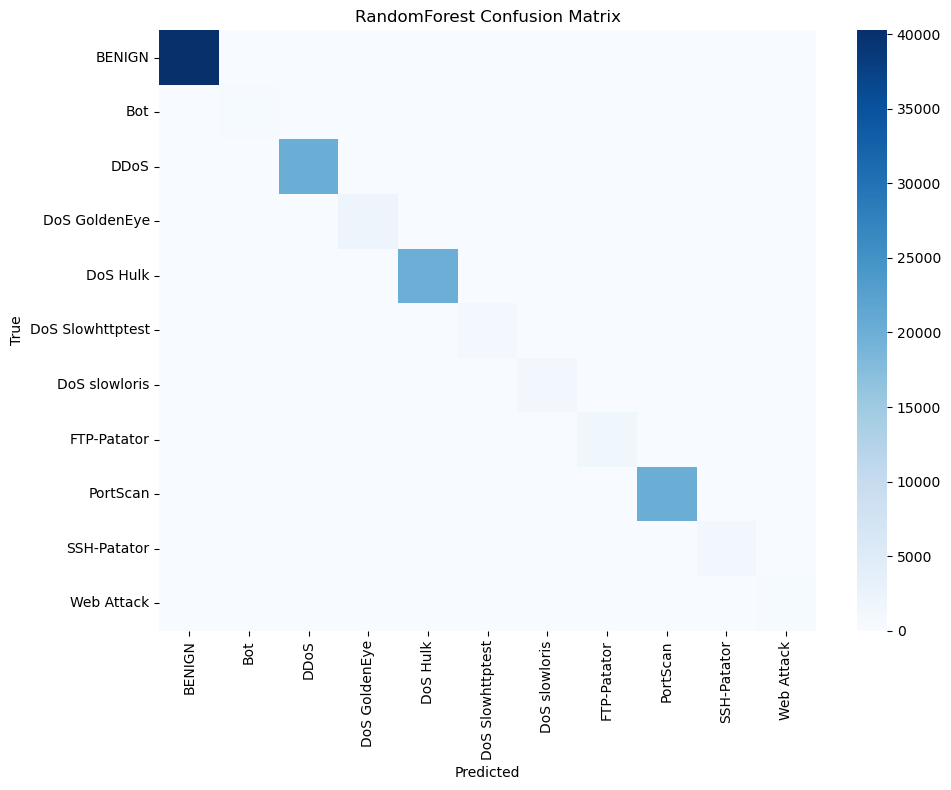

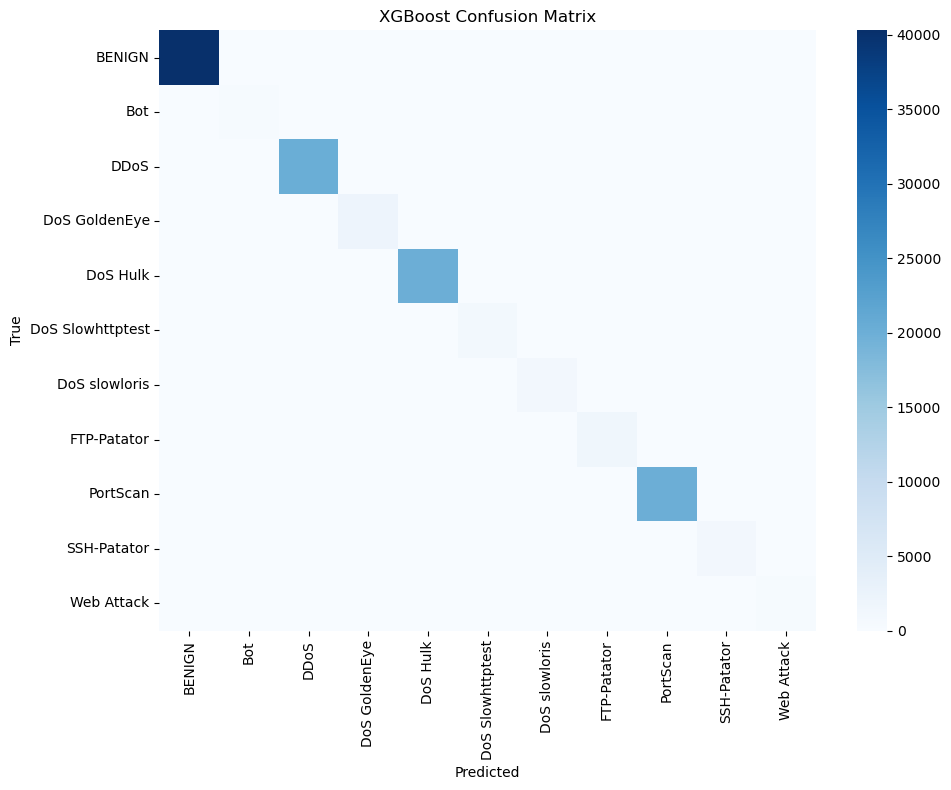

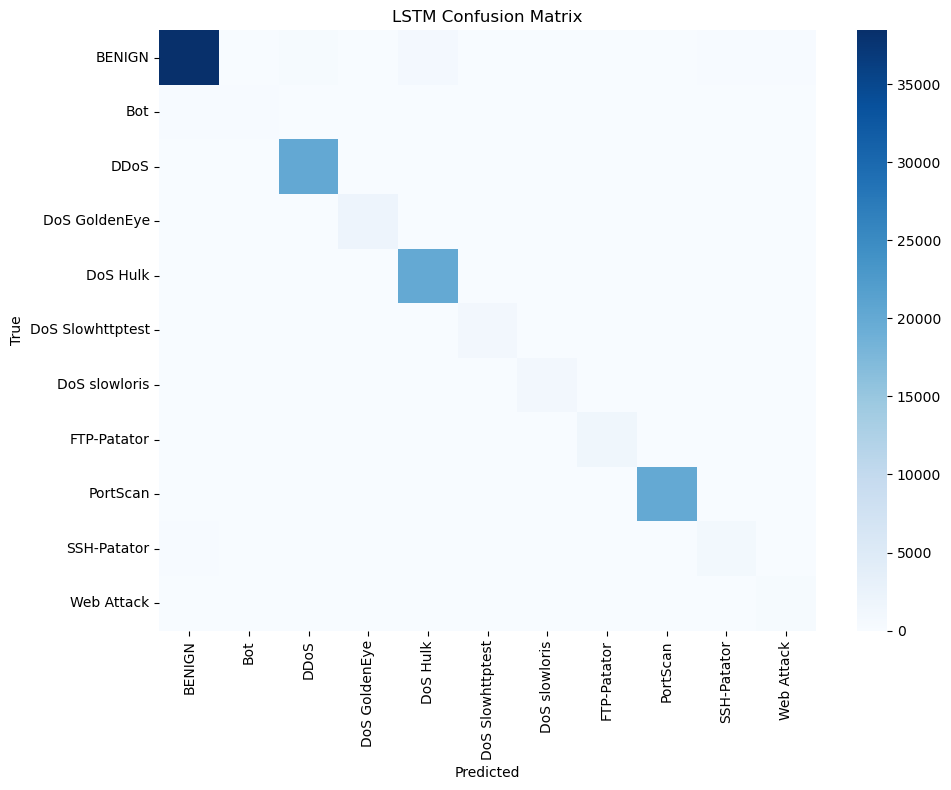

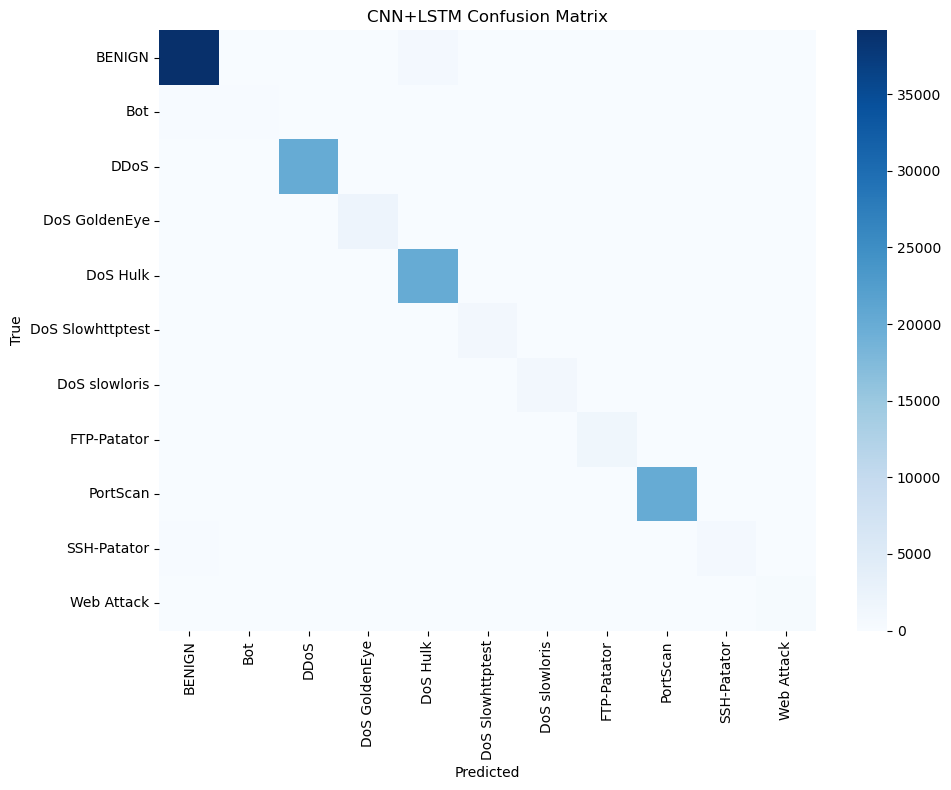

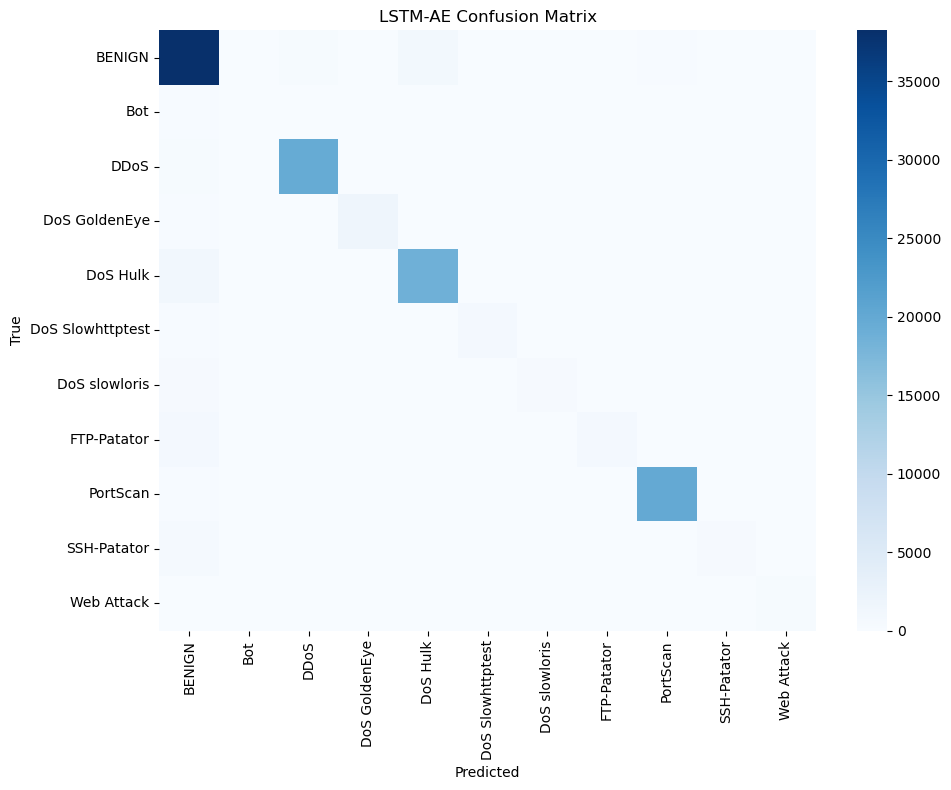

In [54]:
# ============================================================
# 14. Results summary
# ============================================================
results_df = pd.DataFrame(results).sort_values(
    by=["Macro F1", "Macro Recall", "Accuracy"],
    ascending=False
)

print("\n==============================")
print("최종 비교표")
print("==============================")
print(results_df)

results_df.to_csv("benchmark_results_web_grouped.csv", index=False)

# ============================================================
# 15. Confusion matrix for top models
# ============================================================
plot_cm(y_test, rf_pred, "RandomForest Confusion Matrix")
plot_cm(y_test, xgb_pred, "XGBoost Confusion Matrix")
plot_cm(y_test, lstm_pred, "LSTM Confusion Matrix")
plot_cm(y_test, cnn_lstm_pred, "CNN+LSTM Confusion Matrix")
plot_cm(y_test, ae_pred, "LSTM-AE Confusion Matrix")


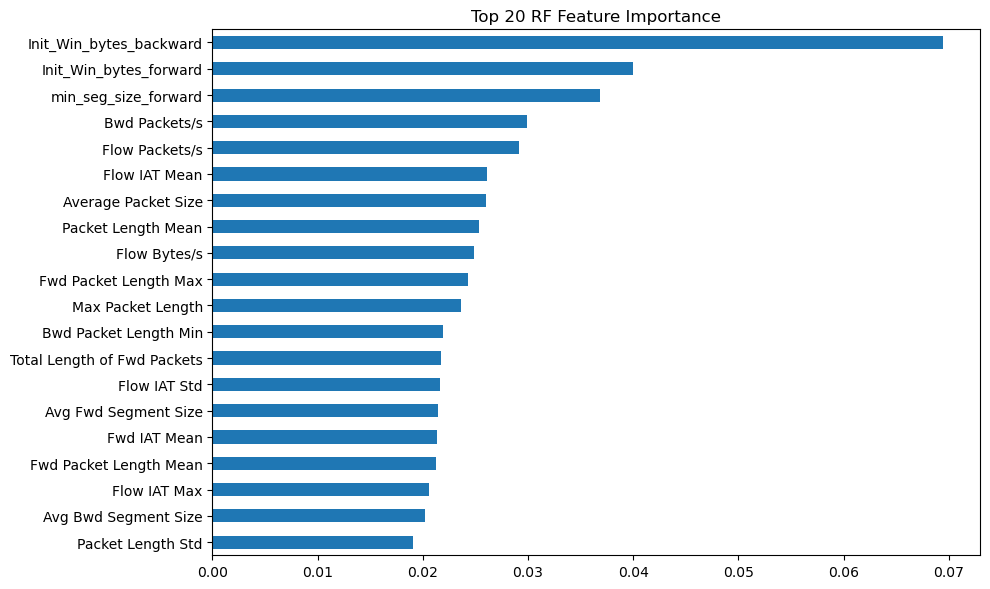

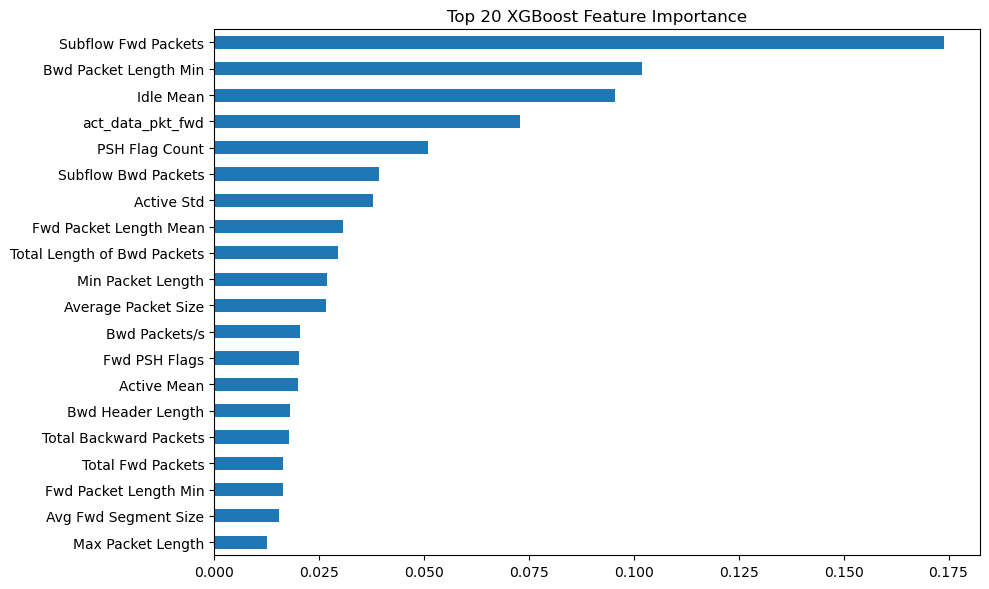


Top 20 RF features:
Init_Win_bytes_backward        0.069481
Init_Win_bytes_forward         0.039965
min_seg_size_forward           0.036864
Bwd Packets/s                  0.029923
Flow Packets/s                 0.029091
Flow IAT Mean                  0.026058
Average Packet Size            0.026028
Packet Length Mean             0.025359
Flow Bytes/s                   0.024813
Fwd Packet Length Max          0.024280
Max Packet Length              0.023644
Bwd Packet Length Min          0.021893
Total Length of Fwd Packets    0.021710
Flow IAT Std                   0.021587
Avg Fwd Segment Size           0.021452
Fwd IAT Mean                   0.021367
Fwd Packet Length Mean         0.021239
Flow IAT Max                   0.020609
Avg Bwd Segment Size           0.020155
Packet Length Std              0.019023
dtype: float64

Top 20 XGBoost features:
Subflow Fwd Packets            0.173812
Bwd Packet Length Min          0.101856
Idle Mean                      0.095426
act_data_pkt_fwd  

In [55]:
# ============================================================
# 16. Feature importance
# ============================================================
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
rf_importance.sort_values().plot(kind="barh")
plt.title("Top 20 RF Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
xgb_importance.sort_values().plot(kind="barh")
plt.title("Top 20 XGBoost Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop 20 RF features:")
print(rf_importance)

print("\nTop 20 XGBoost features:")
print(xgb_importance)